<a href="https://colab.research.google.com/github/PrimeHyAce/Python4DS-Iqbal/blob/main/Copy_of_%F0%9F%A4%96xyether_anime_upscaler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

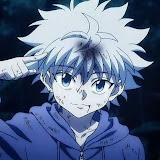

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

# **MADE BY XYETHER** 🤍

this colab uses an anime trained ai model **(REAL-CUGAN)**

since it was only trained on anime it **cant** upscale real-life scenes

VIDEO TUTORIAL : https://youtu.be/NYss3wmZiOM

In [ ]:
# @title #**setup UPSCALING (REAL-CUGAN)**
ROOTPATH="/content/ailab/" # root dir (a constant)
ModelPath=ROOTPATH+"Real-CUGAN/model/" # model dir
FinishPath=ROOTPATH+"Real-CUGAN/finish/" # output dir
ModelName="up2x-latest-denoise3x.pth" # default model
Tile='auto' #{0,1,2,3,4,'auto'}; the larger the number, the smaller the memory consumption
!pip install torch opencv-python
!apt-get install -y ffmpeg
!git clone https://github.com/bilibili/ailab.git

%cd /content/ailab/Real-CUGAN/weights_v3
!wget 'https://drive.google.com/uc?id=1VTBxGhxDM6VETMYLCUU1ISlxuQ9b59Xh' -O up2x-latest-denoise3x.pth

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
Cloning into 'ailab'...
remote: Enumerating objects: 409, done.
remote: Counting objects: 100% (408/408), done.
remote: Compressing objects: 100% (252/252), done.
remote: Total 409 (delta 157), reused 393 (delta 150), pack-reused 1 (from 1)
Receiving objects: 100% (409/409), 14.78 MiB | 44.77 MiB/s, done.
Resolving deltas: 100% (157/157), done.
/content/ailab/Real-CUGAN/weights_v3
--2025-01-14 11:20:43--  https://drive.google.com/uc?id=1VTBxGhxDM6VETMYLCUU1ISlxuQ9b59Xh
Resolving drive.google.com (drive.google.com)... 172.253.117.113, 172.253.117.102, 172.253.117.139, ...
Connecting to drive.google.com (drive.google.com)|172.253.117.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?i

⬆⬆  run this setup  ⬆⬆

In [ ]:
# @title #**UPSCALING**
import sys
sys.path.append("/content/ailab/Real-CUGAN")
import matplotlib.pyplot as plt
%matplotlib inline
import torch
from torch import nn as nn
from torch.nn import functional as F
import os, sys, cv2
import numpy as np
from upcunet_v3 import RealWaifuUpScaler
from time import time as ttime
import ipywidgets as widgets
from IPython.display import display

# Define paths and model parameters
ModelPath = "/content/ailab/Real-CUGAN/weights_v3/"
ModelName = "up2x-latest-denoise3x.pth"

# Define the output folder for processed videos
FinishPath = "/content/ailab/Real-CUGAN/finish/"

# Check if finish directory exists, if not, create it
if not os.path.exists(FinishPath):
    os.makedirs(FinishPath)
    print(f"Output folder '{FinishPath}' created.")

# Define upscale video function
def upscale_video(video_path, scale_factor):
    """Upscale a video using Real-CUGAN."""
    if not os.path.exists(video_path):
        print(f"Error: Video file '{video_path}' not found.")
        return

    # Prepare output path
    video_name = os.path.basename(video_path)
    output_path = os.path.join(FinishPath, f"upscaled_{scale_factor}x_{video_name}")

    # Load model
    print(f"Using model {ModelPath + ModelName}")
    upscaler = RealWaifuUpScaler(scale_factor, ModelPath + ModelName, half=True, device="cuda:0")

    # Open video
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Processing '{video_name}' - Resolution: {width}x{height}, FPS: {fps}, Frames: {frame_count}")

    # Define video writer for upscaled output
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width * scale_factor, height * scale_factor))

    t0 = ttime()
    frame_idx = 0
    start_time = ttime()  # Time when processing starts

    # Process each frame
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_start_time = ttime()  # Time when the current frame starts processing

        try:
            result = upscaler(frame[:, :, [2, 1, 0]], tile_mode=5, cache_mode=2, alpha=1)
            upscaled_frame = result[:, :, ::-1]
            out.write(upscaled_frame)
        except RuntimeError as e:
            print(f"Frame {frame_idx} FAILED: {e}")
        else:
            frame_time = ttime() - frame_start_time  # Time taken for the current frame
            elapsed_time = ttime() - start_time  # Total time elapsed
            estimated_remaining_time = (frame_count - frame_idx - 1) * frame_time
            print(f"Frame {frame_idx + 1}/{frame_count} - Time: {frame_time:.2f}s - Estimated Remaining: {estimated_remaining_time:.2f}s")

        frame_idx += 1

    # Release resources
    cap.release()
    out.release()
    t1 = ttime()

    print(f"'{video_name}' DONE. Upscaled video saved to '{output_path}'")
    print(f"Total time spent: {t1 - t0:.2f} seconds.")

# Widgets
input_video_text = widgets.Text(
    value='',
    placeholder='Enter input video path',
    description='Input Video:',
    layout=widgets.Layout(width='700px')
)

# Button to trigger upscaling
upscale_button = widgets.Button(description="Upscale Video")

output_upscale = widgets.Output()

def on_upscale_clicked(b):
    with output_upscale:
        output_upscale.clear_output()
        video_path = input_video_text.value  # Get video path from widget
        upscale_video(video_path, scale_factor=2)  # Assuming 2x upscaling

upscale_button.on_click(on_upscale_clicked)

# Display the widgets for input and button
display(widgets.VBox([input_video_text, upscale_button, output_upscale]))

ModuleNotFoundError: No module named 'upcunet_v3'

 ⬆⬆ run this after the setup is done ⬆⬆

upscaled video should be saved here: /content/ailab/Real-CUGAN/finish

# **My Socials**

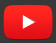

**My** : [YOUTUBE](https://www.youtube.com/@xyether)

.

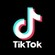

**My** : [TIKTOK](https://www.tiktok.com/@xyether_)

.

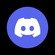

**MY** : [DISCORD SERVER](https://discord.gg/AKyds4Q57f)

contact me on discord if you need help or face any problems

My username:

 [ _vixler ]